## Today {.smaller}

Four sections, and the first two are the ones that make the rest make sense.

1. **Image data.** What an image actually is once it is in memory, and the
   conventions that cause silent bugs.
2. **Convolution.** The operation, its parameters, and the arithmetic you need
   to predict output shapes.
3. **Building a CNN.** The standard parts, then one real network measured
   against the fully connected model you built in Lab 4.
4. **Architectures that mattered.** LeNet through EfficientNet, and what each
   one actually contributed.

Next week is what you build **on top** of a CNN: object detection and image
segmentation.

## Labs and quizzes {.smaller}

**Lab 4 was due yesterday**, Wednesday Sep 30. That was the full training
pipeline: your own `Dataset`, a `DataLoader`, an optimizer comparison, early
stopping, and one look at the test set.

**Quiz 5 is today**, at the end of class. It covers **last week's PyTorch and
training material plus Lab 4**. Nothing from today's deck is on it.

**Lab 5 goes out today**, due Wednesday Oct 7.

One thing to flag about Quiz 5: the format changed. There are four parts now,
and the last one gives you a short training script with bugs in it and asks you
to find them. The study guide and formula sheet on the course site match the new
format.

## What Lab 4 threw away {.smaller}

Your Lab 4 model started with `nn.Flatten()`, then `nn.Linear(784, 256)`. It
reached **0.833** test accuracy on Fashion-MNIST, which is a real result.

But look at what flattening does. A 28x28 image becomes a vector of 784
numbers, in row-major order. Pixel 100 and pixel 128 are directly above and
below each other in the image. After flattening they are 28 apart, which is the
same distance as pixel 100 and pixel 72, and the same distance as pixel 500 and
pixel 528.

`nn.Linear` has no way to know any of that. It sees 784 unrelated inputs. Every
spatial relationship in the image is still **present** in the data, and it is
**invisible** to the layer.

So the layer has to learn, separately, that a vertical edge at position 100 and
a vertical edge at position 300 are the same kind of thing. Nothing shares that
knowledge between positions.

::: {.callout-note}
## The question this deck answers
What layer would use the structure instead of ignoring it?
:::

# Image data

## Where image data comes from {.smaller}

Light from the scene passes through a lens and lands on a sensor: a grid of
millions of photosites.

1. Each photosite **samples** light from one small region of the scene. That is
   where height and width come from.
2. A **colour filter array** sits over the grid, so each photosite measures only
   red, green, or blue. That is where channels come from.
3. A **photodiode** turns arriving photons into electric charge.
4. An **analog-to-digital converter** turns that charge into an integer, usually
   between 0 and 255.

What comes out is a three-dimensional array of integers: height by width by
channels.

Two words for later. **Sampling** is taking measurements at discrete positions
instead of everywhere. **Quantization** is rounding each measurement to one of a
fixed set of levels. Both lose information, and both have failure modes we will
look at.

## An image is a tensor

shape       (1299, 2309, 3)
dtype       uint8
value range [0, 255]
total numbers 8,998,173


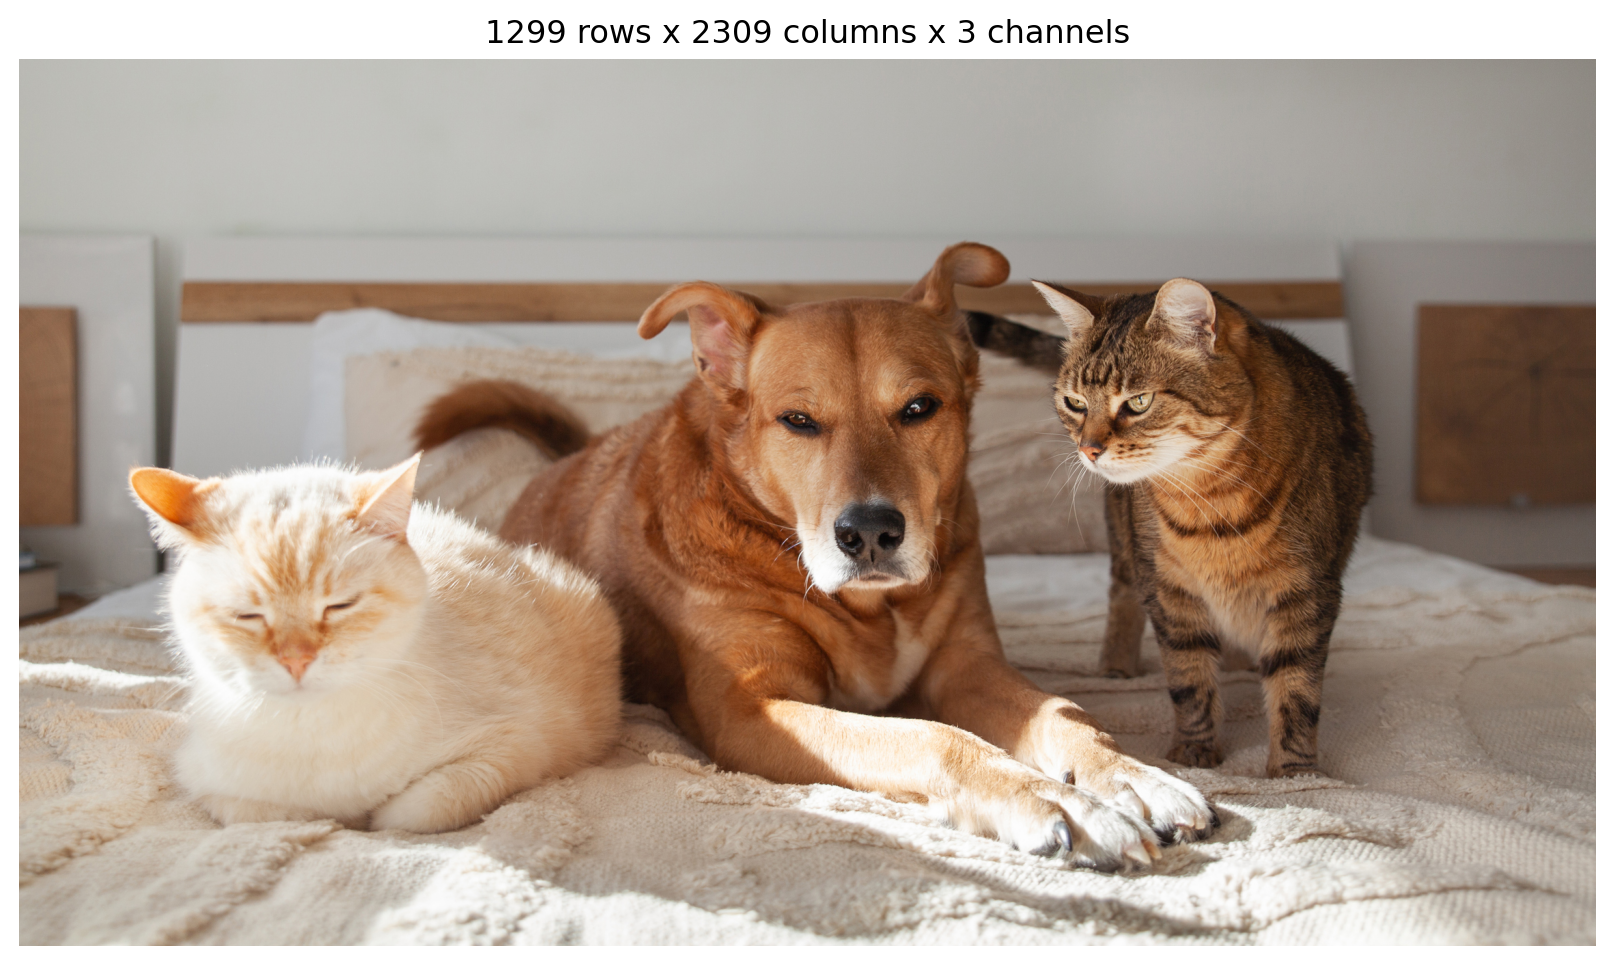

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

pil = Image.open("images/cats-dog.jpg")
img = np.array(pil)

print("shape      ", img.shape)
print("dtype      ", img.dtype)
print("value range", f"[{img.min()}, {img.max()}]")
print("total numbers", f"{img.size:,}")

fig, ax = plt.subplots(figsize=(11, 6))
ax.imshow(img)
ax.set_title(f"{img.shape[0]} rows x {img.shape[1]} columns x "
             f"{img.shape[2]} channels")
ax.axis("off")
plt.show()

## What a pixel is {.smaller}

A pixel is a **measurement from a sensor**. It is not the truth about the scene.

The same object photographed under warm indoor light and under daylight produces
different RGB values. Nothing is broken; the measurement genuinely differs. This
is why "the red channel" is only meaningful relative to the lighting and the
camera's white balance.

Three consequences that matter for training:

- Pixel values carry **noise**, and the noise is larger in dark regions.
- The same object can have very different values across two photographs, which
  is part of why augmentation helps.
- A model trained on one camera's images can get worse on another's.

In [2]:
for row, col in [(260, 390), (250, 1150), (250, 1750)]:
    r, g, b = img[row, col]
    print(f"img[{row}, {col}] = R {r:3d}  G {g:3d}  B {b:3d}")

print()
print("one pixel is a vector of", img.shape[2], "numbers")
print("the whole image is", f"{img.size:,}", "numbers")

img[260, 390] = R 177  G 178  B 173
img[250, 1150] = R 173  G 174  B 169
img[250, 1750] = R 161  G 160  B 156

one pixel is a vector of 3 numbers
the whole image is 8,998,173 numbers


## Channel layout: HWC, CHW and NCHW {.smaller}

The same image can be stored with its axes in different orders, and the
libraries disagree.

| Layout | Shape | Who uses it |
|---|---|---|
| **HWC** | `(height, width, channels)` | NumPy, PIL, matplotlib, OpenCV, TensorFlow |
| **CHW** | `(channels, height, width)` | **PyTorch** |
| **NCHW** | `(batch, channels, height, width)` | PyTorch, batched |
| NHWC | `(batch, height, width, channels)` | TensorFlow, batched |

You have already used NCHW. Lab 4's batches were `(128, 1, 28, 28)`: 128
images, one channel because Fashion-MNIST is greyscale, 28 rows, 28 columns.

`transforms.ToTensor()` does two things at once that are easy to miss. It
converts HWC to CHW, **and** it divides by 255 so values land in `[0, 1]`.

In [3]:
import torch

print("HWC, as loaded       ", img.shape)

chw = np.transpose(img, (2, 0, 1))
print("CHW, axes reordered  ", chw.shape)

nchw = chw[np.newaxis, ...]
print("NCHW, batch axis added", nchw.shape)

t = torch.from_numpy(nchw).float() / 255.0
print("as a float tensor    ", tuple(t.shape), t.dtype,
      f"range [{t.min():.3f}, {t.max():.3f}]")

# The same pixel, found both ways. Reordering axes does not move data.
print()
print("HWC img[250, 1150]   ", img[250, 1150])
print("CHW chw[:, 250, 1150]", chw[:, 250, 1150])

HWC, as loaded        (1299, 2309, 3)
CHW, axes reordered   (3, 1299, 2309)
NCHW, batch axis added (1, 3, 1299, 2309)
as a float tensor     (1, 3, 1299, 2309) torch.float32 range [0.000, 1.000]

HWC img[250, 1150]    [173 174 169]
CHW chw[:, 250, 1150] [173 174 169]


## Coordinate conventions {.smaller}

The origin is the **top left**. Row index grows **downward**. Arrays are indexed
`img[row, column]`.

Matplotlib, and most plotting and annotation code, wants `(x, y)`, which is
`(column, row)`. **The order is reversed.** Swapping them is one of the most
common bugs in vision code, and it does not raise an error. You get a box in the
wrong place, or a transposed image if the dimensions happen to match.

[![](images/fig-coords.png){.dw75}](images/fig-coords.png){target="_blank" .zoom}

## Channel order: RGB and BGR {.smaller}

Most libraries give you RGB. **OpenCV gives you BGR**, for historical reasons.

If you read with OpenCV and display or normalize as if it were RGB, the red and
blue channels are swapped. Nothing raises. The array has the right shape and the
right dtype. Training still runs. The model is just worse, and the reason is
invisible.

[![](images/fig-channel-order.png){.dw75}](images/fig-channel-order.png){target="_blank" .zoom}

## Quantization and bit depth {.smaller}

An 8-bit channel has $2^8 = 256$ possible values per pixel. That is the usual
case. Medical and scientific imaging often use 16 bits, which is 65,536 levels.

Fewer levels means visible **banding**: smooth gradients become flat steps. It
shows up in the smooth regions first, because that is where neighbouring pixels
would otherwise differ by only one or two levels.

[![](images/fig-quantization.png){.dw100}](images/fig-quantization.png){target="_blank" .zoom}

## Dynamic range and normalization {.smaller}

**Dynamic range** is the span between the darkest and brightest values a sensor
can record. Push past either end and the values **clip**: everything brighter
than the maximum records as 255, everything darker than the minimum records as
0.

Clipped values are gone. Scaling the image back down afterwards does not return
them, because the differences that distinguished them were never recorded.

[![](images/fig-dynamic-range.png){.dw100}](images/fig-dynamic-range.png){target="_blank" .zoom}

In the overexposed panel, **65.9%** of all subpixel values are pinned at exactly
255. In the underexposed panel, **37.7%** are at or below 16.

## Why models normalize their inputs {.smaller}

Week 5 covered the reason: when inputs sit on very different scales, one
learning rate cannot suit all of them. Images have a milder version of the same
problem, so the convention is to **standardize** each channel, meaning subtract
a mean and divide by a standard deviation.

$$x' = \frac{x - \mu_c}{\sigma_c}$$

The ImageNet statistics are the ones you will meet most often, because most
pretrained backbones are ImageNet classifiers. They are **not** universal:

[![](images/fig-preprocessing.png){.dw92}](images/fig-preprocessing.png){target="_blank" .zoom}

So do not hard-code the constants. `weights.transforms()` gives you the exact
preprocessing those weights were trained with. Next week we measure what happens
when you get this wrong.

## Resolution {.smaller}

Resolution is **sampling density**: how many measurements you take across the
scene. More samples means more detail, more memory, and more compute.

Downsampling discards information permanently.

[![](images/fig-resolution.png){.dw100}](images/fig-resolution.png){target="_blank" .zoom}

## Upsampling does not undo downsampling {.smaller}

Interpolation fills in plausible values between the samples you kept. It cannot
recover the samples you threw away.

[![](images/fig-upsample.png){.dw90}](images/fig-upsample.png){target="_blank" .zoom}

Bilinear interpolation gives you a smooth guess, nearest-neighbour gives you
blocks, and neither gives you the whiskers back. Keep this in mind for next
week: segmentation networks have to upsample, and this is the problem they are
fighting.

## Aliasing {.smaller}

**Aliasing** is when detail finer than your sampling grid shows up as a
different, coarser pattern that was never in the scene. The fix is to **blur
before you shrink**, so detail too fine to represent is gone before it can
masquerade as something coarser.

[![](images/fig-aliasing.png){.dw89}](images/fig-aliasing.png){target="_blank" .zoom}

Without a filter the whiskers break into speckles and the coat turns to noise.
In torchvision, `transforms.Resize(antialias=True)` is the default now and did
not used to be.

## Data augmentation {.smaller}

**Data augmentation** is applying random, label-preserving transformations to
training images, so the model sees a different version of each example every
epoch.

It is a regularizer. Week 5 covered dropout and weight decay, which constrain
the model. Augmentation works on the other side: it enlarges the training
distribution.

```python
from torchvision import transforms as T

train_tf = T.Compose([               # random, different every epoch
    T.RandomResizedCrop(224),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(mean, std),
])

eval_tf = T.Compose([                # deterministic, always the same
    T.Resize(256), T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean, std),
])
```

The two pipelines are **different on purpose**. Randomness at evaluation time
would make your validation score depend on the dice roll.

## Augmentation, applied {.smaller}

[![](images/fig-augmentation.png){.dw100}](images/fig-augmentation.png){target="_blank" .zoom}

Every panel still shows a dog and two cats, which is the requirement: the
transformation must not change the label.

That requirement is easy to break. A horizontal flip is safe for animals and
**wrong for handwritten digits and text**, where it changes what the symbol is.
A 180 degree rotation is safe for satellite imagery and wrong for street scenes.
Augmentation choices are claims about which variations your task should ignore.

## Automatic augmentation policies {.smaller}

The pipeline two slides ago was hand-written. Which transforms, at what
strength? That literature moved toward **less** tuning, not more.

- **AutoAugment** (2019) searched for a policy with reinforcement learning, at a
  cost of thousands of GPU hours, and published one policy per dataset.
  `torchvision` ships the three it found.
- **RandAugment** (2020) showed the search was mostly unnecessary: pick 2
  transforms at random from a list of 14 and apply both at one strength.
- **TrivialAugment** (2021) removed even those two numbers. One random
  transform at one random strength per image, and nothing to tune.

[![](images/fig-augment-policies.png){.dw92}](images/fig-augment-policies.png){target="_blank" .zoom}

## What augmentation is worth, measured {.smaller}

`torchvision` published the recipe that took ResNet-50 from **76.13% to 80.86%**
on ImageNet with the architecture completely unchanged, and the contribution of
each step.

[![](images/fig-recipe-ablation.png){.dw100}](images/fig-recipe-ablation.png){target="_blank" .zoom}

Augmentation accounts for **1.08 of the 4.73 points**. The largest single step is
longer training, and that only pays off because the augmentation is strong enough
to keep a longer run from overfitting. In this recipe, the aggressive and
untuned `TrivialAugmentWide` beat both AutoAugment and RandAugment.

**Mixup** and **CutMix** break the label-preserving rule on purpose: they combine
two images and combine their labels in the same proportion, so the target
becomes `0.7 cat + 0.3 dog` rather than one class.

# Convolution

## Why a fully connected layer is wrong for images {.smaller}

Take a 224x224 colour image, which is the standard size for pretrained models,
and send it to a modest hidden layer of 1024 units.

In [4]:
import torch.nn as nn

fc   = nn.Linear(224 * 224 * 3, 1024)
conv = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3)

n_fc   = sum(p.numel() for p in fc.parameters())
n_conv = sum(p.numel() for p in conv.parameters())

print(f"Linear(224*224*3, 1024)  {n_fc:>12,} parameters")
print(f"Conv2d(3, 32, 3)         {n_conv:>12,} parameters")
print(f"ratio                    {n_fc / n_conv:>12,.0f}x")

Linear(224*224*3, 1024)   154,141,696 parameters
Conv2d(3, 32, 3)                  896 parameters
ratio                         172,033x


## Two problems, not one {.smaller}

**The parameter count.** 154 million parameters in one layer. That is more than
VGG-16 has in its entirety, and it is the first layer of a network that has not
done anything yet.

**The one that matters more.** A dense layer learns an independent weight for
every input position. If it learns to detect a vertical edge in the top left, it
has learned nothing about vertical edges in the bottom right. That knowledge is
not shared, so it must be learned again, from separate examples, for every
position.

An edge is an edge wherever it appears. That is a fact about images, and it is a
fact a dense layer cannot use.

Convolution is the layer that uses it. Two ideas do all the work:

- **Locality.** A unit looks at a small neighbourhood, not the whole image.
- **Weight sharing.** The same small set of weights is applied at every
  position.

## The convolution operation {.smaller}

A small grid of weights, the **kernel**, slides across the input. At each
position it multiplies the overlapping values elementwise and sums them. That
single number becomes one output value.

[![](images/fig-conv-anim.gif){.dw80}](images/fig-conv-anim.gif){target="_blank" .zoom}

A 5x5 input and a 3x3 kernel give a 3x3 output, because there are only 3x3
positions where the kernel fits entirely inside the input.

## Definition of a convolutional layer {.smaller}

For a single-channel input $X$ and one $K \times K$ kernel $W$:

$$
Y_{i,j} = \sum_{m=1}^{K}\sum_{n=1}^{K} X_{i+m-1,\;j+n-1}\, W_{m,n} + b
$$

The learned parameters are the $K^2$ kernel weights and one bias.

**Worked example.** The patch, the kernel and the bias:

$$
X_{\text{patch}}=\begin{bmatrix} 1 & 0 & 2 \\ -1 & 3 & 1 \\
0 & 2 & -2 \end{bmatrix},\quad
W=\begin{bmatrix} 1 & 0 & -1 \\ 1 & 0 & -1 \\ 1 & 0 & -1
\end{bmatrix},\quad b=2
$$

Multiply elementwise, add the nine products, add the bias:

$$
Y = \big[(1)(1) + (2)(-1) + (-1)(1) + (1)(-1) + (0)(1) + (-2)(-1)\big] + 2
= -1
$$

Note what the kernel does: it subtracts the right column from the left column
and ignores the middle. That is a vertical edge detector.

## Convolution over channels {.smaller}

A real image has 3 channels, and a layer in the middle of a network may have
256. So a kernel is not $K \times K$. It is $K \times K \times C_{\text{in}}$,
and it sums over channels as well as over space.

For $C_{\text{in}}$ input channels and $F$ filters:

$$
Y_{i,j,f} = \sum_{c=1}^{C_{\text{in}}}\sum_{m=1}^{K}\sum_{n=1}^{K}
X_{i+m-1,\;j+n-1,\;c}\, W_{m,n,c,f} + b_f
$$

[![](images/cnn-multi-channel-cnn.png){.dw60}](images/cnn-multi-channel-cnn.png){target="_blank" .zoom}

So one filter has $K^2 C_{\text{in}}$ weights and one bias, and a layer with
$F$ filters has $F(K^2 C_{\text{in}} + 1)$ parameters in total. That formula is
worth memorizing; it is on the formula sheet.

## Filters and feature maps {.smaller}

One filter produces **one** output channel, called a **feature map**. It records
how strongly that filter responded at every position.

A layer with $F$ filters produces $F$ feature maps, stacked into one output
tensor. Different filters learn to respond to different things.

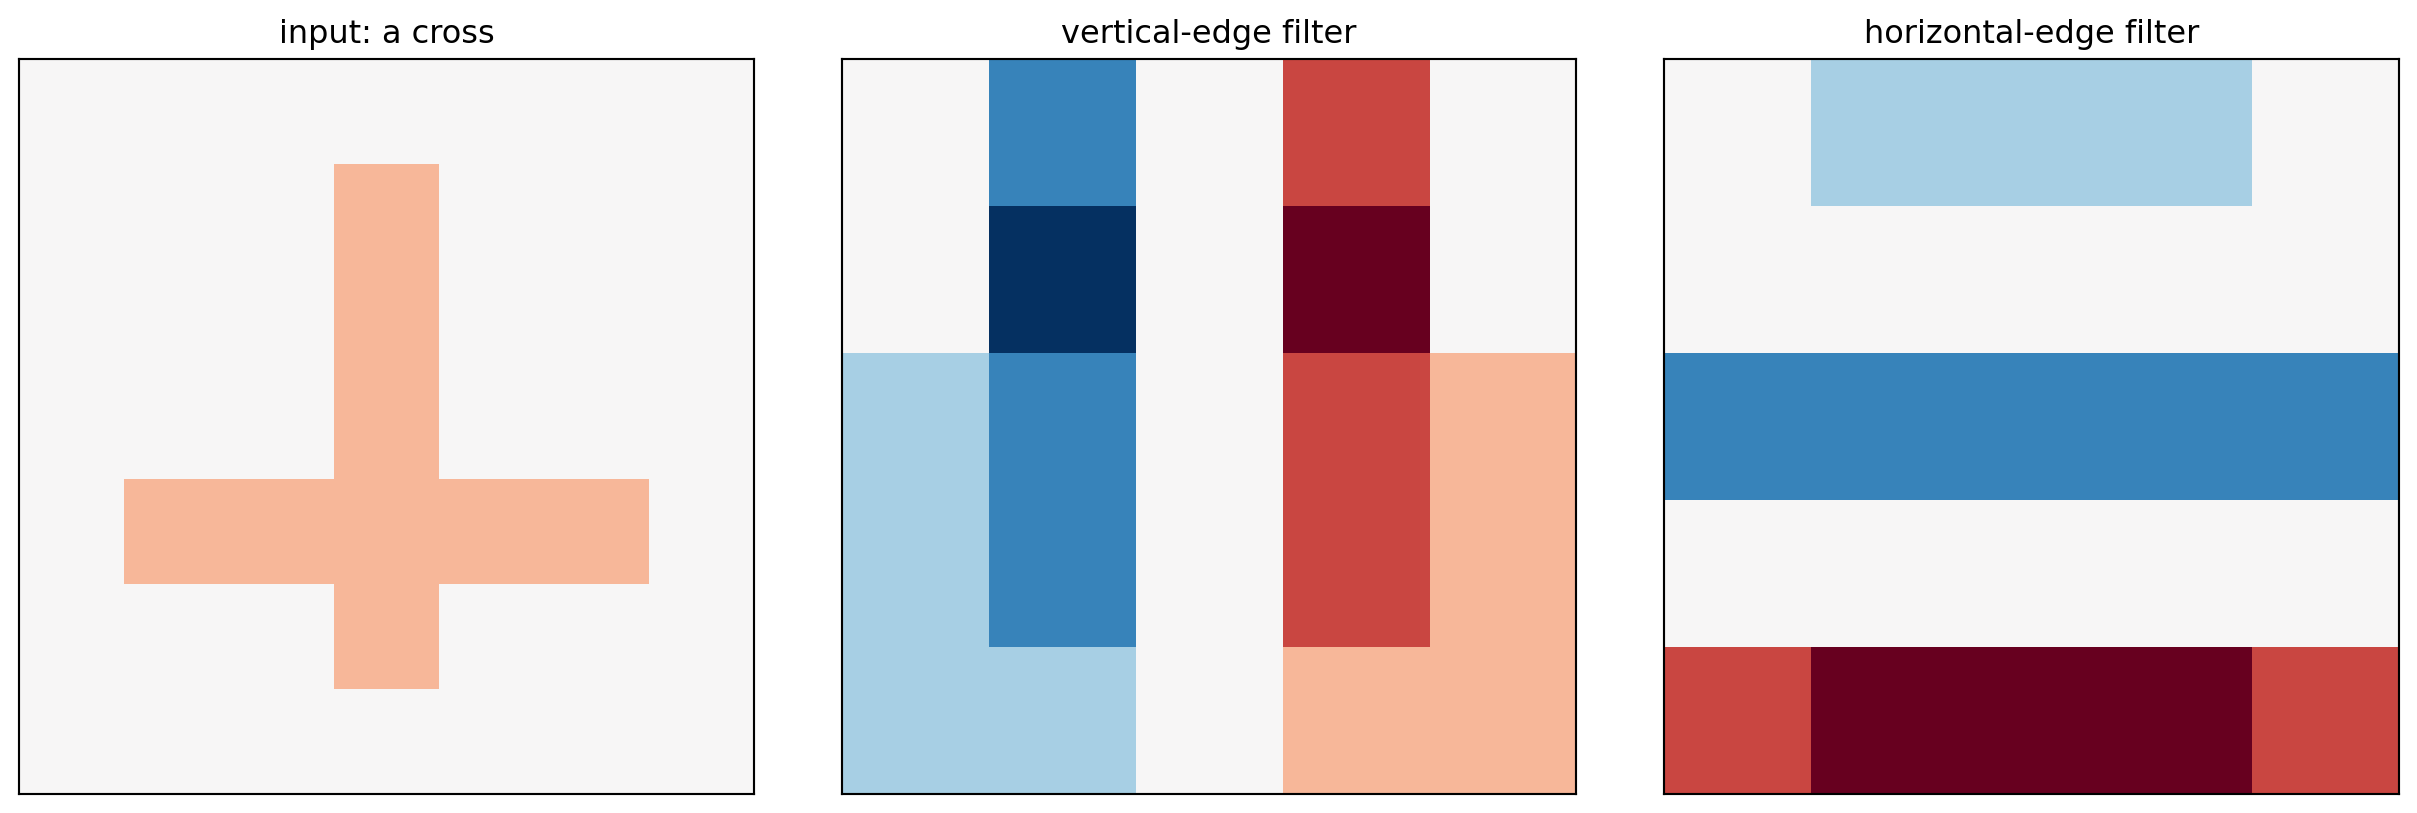

two filters, same input, two different feature maps


In [5]:
import torch.nn.functional as F

x = torch.zeros(7, 7)
x[1:6, 3] = 1.0     # a vertical line
x[4, 1:6] = 1.0     # a horizontal line

k_vert  = torch.tensor([[1., 0., -1.]] * 3)            # left minus right
k_horiz = k_vert.T.contiguous()                        # top minus bottom

y_vert  = F.conv2d(x[None, None], k_vert[None, None])[0, 0]
y_horiz = F.conv2d(x[None, None], k_horiz[None, None])[0, 0]

fig, ax = plt.subplots(1, 3, figsize=(13, 4.2))
for a, (d, t) in zip(ax, [(x, "input: a cross"),
                          (y_vert, "vertical-edge filter"),
                          (y_horiz, "horizontal-edge filter")]):
    a.imshow(d, cmap="RdBu_r", vmin=-3, vmax=3)
    a.set_title(t); a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

print("two filters, same input, two different feature maps")

## A hand-set filter on a real image {.smaller}

Nine numbers, chosen by hand, no training at all.

[![](images/fig-sobel.png){.dw70}](images/fig-sobel.png){target="_blank" .zoom}

This is what "feature detector" means concretely. A CNN does not get these
kernels from you. It starts from random values and the gradient of the loss
moves them toward whatever is useful, which in the first layer turns out to look
a lot like this.

## Weight sharing and translation equivariance {.smaller}

The same kernel is applied at every position, so the layer has $K^2
C_{\text{in}} + 1$ parameters no matter how large the image is. A 4K image and
a thumbnail use the same weights.

The second consequence has a name. **Translation equivariance** means that if
you shift the input, the output shifts by the same amount:

$$
\text{conv}(\text{shift}(X)) = \text{shift}(\text{conv}(X))
$$

Be careful with the vocabulary, because the two words get mixed up constantly:

- **Equivariance**: the output moves with the input. Convolution has this.
- **Invariance**: the output does not change when the input moves. Convolution
  does **not** have this. Pooling adds a little, and global pooling at the end
  of the network adds a lot.

Equivariance is the useful property for a feature extractor. You want to know
*where* the edge is, not just that there is one somewhere.

## Padding and output size {.smaller}

Without padding, each convolution shrinks the image by $K-1$ pixels, so a stack
of layers runs out of image. **Padding** adds a border of zeros so the output
can keep the input's size.

$$
H_{\text{out}}=\left\lfloor\frac{H+2P-K}{S}\right\rfloor+1,
\qquad
W_{\text{out}}=\left\lfloor\frac{W+2P-K}{S}\right\rfloor+1
$$

$H, W$ are the input height and width, $K$ the kernel size, $P$ the padding on
each side, $S$ the stride, and $\lfloor\cdot\rfloor$ rounds down.

**Two cases worth knowing by heart.**

$K=3, P=1, S=1$ keeps the size exactly: $(H + 2 - 3) + 1 = H$. This is why 3x3
with padding 1 is everywhere.

ResNet's first layer is $K=7, P=3, S=2$ on a 224 input:
$\lfloor(224 + 6 - 7)/2\rfloor + 1 = 112$. Halved.

And the earlier example, $H=32, K=3, P=1, S=2$:
$\lfloor 31/2 \rfloor + 1 = 16$.

## Stride {.smaller}

**Stride** is how far the kernel moves between positions. Stride 1 visits every
position; stride 2 skips every other one, which roughly halves the output's
height and width.

[![](images/fig-stride-anim.gif){.dw80}](images/fig-stride-anim.gif){target="_blank" .zoom}

A 5x5 input with a 3x3 kernel at stride 2 gives a 2x2 output. Fewer positions
means less compute and a smaller output, at the cost of skipping detail.

## Pooling {.smaller}

**Pooling** reduces spatial size with a fixed rule and no learned parameters.
Max pooling takes the largest value in each window. Average pooling takes the
mean.

[![](images/fig-pool-anim.gif){.dw80}](images/fig-pool-anim.gif){target="_blank" .zoom}

Max pooling keeps the strongest response and discards where in the window it
was, which is where a small amount of translation invariance comes from. Average
pooling keeps a smoother summary.

## Pooling against strided convolution {.smaller}

Both shrink the feature map. They are not the same thing.

:::: {.columns .contrast}
::: {.column}
### Pooling {.col-yes}
- No parameters. The rule is fixed before training.
- Max pooling is nonlinear.
- Cheap, and one less thing to learn.
- Discards position within the window, on purpose.
:::
::: {.column}
### Strided convolution {.col-no}
- Learns how to downsample.
- One operation instead of two.
- More parameters and more compute.
- Modern architectures mostly prefer this.
:::
::::

The practical summary: classification benefits from throwing position away, so
pooling is fine and common. Segmentation and detection need position, so
aggressive pooling hurts them, and that tension drives most of next week's
architectures.

## Receptive field {.smaller}

The **receptive field** of an output unit is the region of the **input** that
can affect its value.

One 3x3 layer gives a 3x3 receptive field. Stack another and it is 5x5. Each
3x3 layer with stride 1 adds 2.

[![](images/fig-receptive-field.png){.dw85}](images/fig-receptive-field.png){target="_blank" .zoom}

So why not use one big kernel instead of stacking small ones?

## Why small kernels, stacked {.smaller}

Two 3x3 convolutions and one 5x5 convolution see the same 5x5 input region.
Compare them at 64 input and 64 output channels:

| | Parameters | Receptive field | Nonlinearities |
|---|---|---|---|
| One `Conv2d(64, 64, 5)` | 102,464 | 5x5 | 1 |
| Two `Conv2d(64, 64, 3)` | **73,856** | 5x5 | **2** |

The stack is **28% smaller** and puts an activation function in the middle, so
it can represent more. This is the observation VGG was built on, and it is why
3x3 is the default kernel size in almost every architecture since 2014.

The cost is depth. More layers means a longer path for gradients, which is the
problem residual connections were invented to solve.

## `nn.Conv2d` {.smaller}

```python
nn.Conv2d(in_channels, out_channels, kernel_size,
          stride=1, padding=0, bias=True)
```

`in_channels` must match the channel count of whatever comes in.
`out_channels` is the number of filters, so it is the channel count coming out.

In [6]:
layer = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)

x = torch.randn(8, 3, 32, 32)       # NCHW: 8 images, 3 channels, 32x32
y = layer(x)

print("input ", tuple(x.shape))
print("output", tuple(y.shape))
print()
print("weight", tuple(layer.weight.shape), "= (out, in, K, K)")
print("bias  ", tuple(layer.bias.shape))

by_hand = 16 * (3 * 3 * 3 + 1)      # F * (K*K*C_in + 1)
counted = sum(p.numel() for p in layer.parameters())
print()
print(f"F * (K*K*C_in + 1) = 16 * (27 + 1) = {by_hand}")
print(f"actual parameter count            = {counted}")

input  (8, 3, 32, 32)
output (8, 16, 32, 32)

weight (16, 3, 3, 3) = (out, in, K, K)
bias   (16,)

F * (K*K*C_in + 1) = 16 * (27 + 1) = 448
actual parameter count            = 448


# Building a CNN

## The shape of a CNN {.smaller}

Almost every convolutional classifier is the same three-part skeleton.

**Body.** A block repeated several times:

```
Conv2d -> BatchNorm2d -> ReLU  (often twice)  -> downsample
```

**Downsampling** between blocks, by pooling or by stride.

**Head.** Collapse the spatial dimensions and produce one score per class.

The pattern across the body is that **spatial size falls while channel count
rises**. A 224x224x3 input becomes 7x7x512 in ResNet-18.

That trade is the whole design. You give up knowing exactly *where* things are
and buy the ability to represent *what* is there. Early layers know position
precisely and meaning barely; late layers know meaning well and position only
coarsely.

## Activations in convolutional networks {.smaller}

Week 2 covered why a nonlinearity is needed at all: without one, stacked linear
layers collapse into a single linear layer. Nothing about that changes here.

What changes is which one you reach for.

$$
\mathrm{ReLU}(x)=\max(0,x), \qquad
\mathrm{LeakyReLU}(x)=\max(\alpha x, x), \qquad
\mathrm{GELU}(x)=x\,\Phi(x)
$$

**ReLU is the default** in convolutional networks. Sigmoid and tanh saturate:
once a unit's input is large, the derivative is near zero and the gradient
stops. In a 50-layer network that is fatal, and it is the same vanishing
gradient problem from Week 5, arriving through the activation function instead
of through the weights.

LeakyReLU keeps a small slope for negative inputs, so a unit that has gone
negative can still recover. GELU is smoother and is standard in transformers,
which is Week 9.

## Batch normalization {.smaller}

**Batch normalization** standardizes each channel's activations using the mean
and variance computed across the current mini-batch, then applies a learned
scale and shift.

$$
\hat{x}=\frac{x-\mu_{B}}{\sqrt{\sigma_{B}^{2}+\epsilon}},
\qquad y=\gamma\hat{x}+\beta
$$

$\mu_B$ and $\sigma^2_B$ come from the batch. $\gamma$ and $\beta$ are
learned, one pair per channel, so the layer can undo the normalization if that
is what minimizes the loss.

What it buys you: higher learning rates without diverging, much less sensitivity
to how you initialized, and faster convergence. It is in essentially every CNN
from 2015 onward.

There is a catch, and it is the kind that wastes an afternoon.

## BatchNorm behaves differently in eval mode {.smaller}

At test time you may have one image, so there is no batch to compute statistics
from. BatchNorm therefore keeps a **running estimate** of the mean and variance
during training, and uses those in `eval()` mode instead of batch statistics.

The estimate is an exponential moving average, so it **lags** the weights.

[![](images/fig-batchnorm-eval.png){.dw75}](images/fig-batchnorm-eval.png){target="_blank" .zoom}

Both curves are the same weights on the same images. Only `eval()` wobbles,
because only `eval()` uses the lagging statistics.

If validation accuracy is wild while training accuracy is smooth, suspect the
BatchNorm statistics before the model. Decaying the learning rate settles them,
because the weights stop moving.

## 1x1 convolutions {.smaller}

A 1x1 kernel looks like it cannot do anything. It sees one spatial position.

But it still sums over **channels**. A `Conv2d(256, 64, 1)` takes the 256-number
vector at each position and maps it to a 64-number vector, using the same
mapping at every position. It is a fully connected layer applied across
channels only.

That makes it the cheap way to change channel count:

```python
nn.Conv2d(256, 64, kernel_size=1)   # 256*64 + 64 = 16,448 parameters
nn.Conv2d(256, 64, kernel_size=3)   # 9*256*64 + 64 = 147,520 parameters
```

Nine times fewer parameters for the job of "fewer channels now".

This shows up three times in the next section. Inception uses 1x1 to shrink
channels before an expensive 5x5. ResNet's bottleneck blocks use 1x1 to go down
and back up around a 3x3. MobileNet's pointwise convolution **is** a 1x1.

## Global average pooling against flatten {.smaller}

The head has to turn a `(C, H, W)` feature map into `num_classes` scores. Two
ways.

**Flatten, then a linear layer.** VGG-16 ends with a 7x7x512 feature map,
flattens it to 25,088 numbers, and sends that to a 4096-unit layer. That one
layer has over 102 million parameters, which is most of VGG's 138 million. And
because 25,088 is baked into the layer's shape, the network only accepts
224x224 inputs.

**Global average pooling.** Average each channel over all positions. A 7x7x512
map becomes 512 numbers, with no parameters at all, then one `Linear(512, 10)`.

```python
nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(512, 10)
```

This is what ResNet and everything after it does. Far fewer parameters, less
overfitting, and the network accepts any input size large enough to survive the
downsampling.

## Residual connections {.smaller}

:::: {.columns}
::: {.column width="62%"}
A **residual connection** adds a layer block's input to its output:

$$
\mathbf{y}=\mathcal{F}(\mathbf{x})+\mathbf{x}
$$

So the block only has to learn the **difference** between what it is given and
what is wanted, which is where "residual" comes from.

Why it helps is easiest to see in the backward pass. The derivative of
$\mathbf{y}$ with respect to $\mathbf{x}$ is

$$
\frac{\partial \mathbf{y}}{\partial \mathbf{x}}
= \frac{\partial \mathcal{F}}{\partial \mathbf{x}} + I
$$

That $+I$ is the point. Even if the block's own term is tiny, the gradient still
has a route back through the identity. Multiply many such terms together and
you get sums involving 1 instead of products of small numbers.

If the shapes do not match, a 1x1 convolution on the shortcut fixes them.
:::
::: {.column width="38%"}
[![](images/residual-block.png){.dh420}](images/residual-block.png){target="_blank" .zoom}
:::
::::

## A small CNN in PyTorch {.codetight}

In [7]:
cnn = nn.Sequential(
    nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
    nn.MaxPool2d(2),                                        # 28 -> 14
    nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
    nn.MaxPool2d(2),                                        # 14 -> 7
    nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
    nn.Conv2d(128, 96, 3, padding=1), nn.BatchNorm2d(96), nn.ReLU(),
    nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(96, 10),
)

z = torch.randn(4, 1, 28, 28)        # a Fashion-MNIST batch of 4
for layer in cnn:
    z = layer(z)
    if isinstance(layer, (nn.Conv2d, nn.MaxPool2d, nn.Linear,
                          nn.AdaptiveAvgPool2d, nn.Flatten)):
        print(f"{layer.__class__.__name__:18s} -> {tuple(z.shape)}")

print()
print(f"total parameters: {sum(p.numel() for p in cnn.parameters()):,}")

Conv2d             -> (4, 32, 28, 28)
MaxPool2d          -> (4, 32, 14, 14)
Conv2d             -> (4, 64, 14, 14)
MaxPool2d          -> (4, 64, 7, 7)
Conv2d             -> (4, 128, 7, 7)
Conv2d             -> (4, 96, 7, 7)
AdaptiveAvgPool2d  -> (4, 96, 1, 1)
Flatten            -> (4, 96)
Linear             -> (4, 10)

total parameters: 204,970


## The same budget, two ways {.smaller}

Lab 4's model was `Linear(784, 256)` then `Linear(256, 10)`: **203,530**
parameters. The CNN on the previous slide has **204,970**. Within 1% of each
other, so capacity is not the variable.

Same 12,000 Fashion-MNIST training images, same 2,000 validation images, same
AdamW at the same learning rate, same cosine schedule, same 18 epochs. The only
difference is the architecture.

[![](images/fig-cnn-vs-mlp.png){.dw95}](images/fig-cnn-vs-mlp.png){target="_blank" .zoom}

**0.8735 against 0.9200.** The CNN is 4.7 points better, which is an error rate
of 8.0% instead of 12.7%, so **37% of the remaining errors are gone**. At the
same parameter count, on the same data, in the same time.

That difference is locality and weight sharing. Nothing else changed.

## What the first layer learns {.smaller}

These are the actual 64 kernels in the first layer of a trained ResNet-18, each
one 7x7x3, shown as colour patches. 9,408 numbers in total.

[![](images/fig-resnet-filters.png){.dw95}](images/fig-resnet-filters.png){target="_blank" .zoom}

Nobody specified these. They are oriented edges at various angles, and
colour-opponent blobs. Minimizing cross entropy on ImageNet produced them,
and they look remarkably like the hand-set Sobel kernel from earlier, and
remarkably like what the early visual system in mammals does.

## What the deeper layers hold {.smaller}

The same network, run on our image. Six strongest channels at four depths.

[![](images/fig-feature-maps.png){.dh480}](images/fig-feature-maps.png){target="_blank" .zoom}

`layer1` is 56x56 and still looks like the photograph. `layer4` is 7x7 and does
not. Position has been traded for meaning, exactly as the skeleton slide
described, and the 512 numbers per position at the end are what a classifier
head actually reads.

# Architectures that mattered

## Timeline {.smaller}

[![](images/jfh-timeline.png){.dh480}](images/jfh-timeline.png){target="_blank" .zoom}

Six ideas, roughly one per architecture, and each one is still in use. The rest
of this section is what each contributed.

## LeNet-5, 1989 to 1998 {.smaller}

[![](images/jfh-lenet5.png){.dw75}](images/jfh-lenet5.png){target="_blank" .zoom}

Yann LeCun's network for reading handwritten digits on cheques. Roughly 60,000
parameters.

Everything structural is already here: convolution, subsampling, repeated
blocks, then fully connected layers to the output. What it lacked was data,
compute, and ReLU. It used tanh and was trained on CPUs in the 1990s.

It worked, in production, on real cheques. Then the field moved to other methods
for over a decade.

## AlexNet, 2012 {.smaller}

:::: {.columns}
::: {.column width="56%"}
The ImageNet result that restarted the field. Top-5 error fell from about 26% to
about 16% in one year, which was not an incremental improvement.

What was actually new:

- **ReLU** instead of tanh, so deep stacks trained in reasonable time.
- **Two GPUs**, which is why the published diagram is split into two parallel
  streams.
- **Dropout** in the fully connected layers.
- **Augmentation**: random crops and flips.
- **ImageNet**: 1.2 million labelled images, which did not exist before.

61.1 million parameters, 56.5% top-1 accuracy.
:::
::: {.column width="44%"}
[![](images/jfh-alexnet.png){.dh420}](images/jfh-alexnet.png){target="_blank" .zoom}
:::
::::

The architecture was not the breakthrough. The combination of enough data,
enough compute, and ReLU was.

## VGG, 2014 {.smaller}

[![](images/cnn-kernels-filters.png){.dw85}](images/cnn-kernels-filters.png){target="_blank" .zoom}

One design rule, applied uniformly: **every convolution is 3x3 with padding 1**,
and you go deeper instead of wider. Downsampling is 2x2 max pooling. That is the
whole architecture.

This is the slide from earlier made into a network: two 3x3 layers beat one 5x5
on parameters and on expressiveness, so use many small kernels.

VGG-16 has 16 weight layers and 138 million parameters, and **102 million of
them are in the first fully connected layer**. The convolutional part is only
about 15 million.

## VGG-16 {.smaller}

[![](images/vgg-16.png){.dh500}](images/vgg-16.png){target="_blank" .zoom}

## VGG configurations {.smaller}

:::: {.columns}
::: {.column width="46%"}
The paper's table of the family, from 11 to 19 weight layers. Reading it is a
useful exercise: each column is one network, and the only thing that changes
down a column is how many 3x3 convolutions sit in each block.

Two details worth noticing:

- The channel count doubles after each pooling stage: 64, 128, 256, 512, 512.
  Spatial size halves, channels double. That keeps the compute per block roughly
  constant and is a convention you will see everywhere.
- All three fully connected layers are identical across every variant, which is
  where the parameters are.
:::
::: {.column width="54%"}
[[![](images/vgg-configurations.png){.dh440}](images/vgg-configurations.png){target="_blank" .zoom}](https://arxiv.org/pdf/1409.1556#page=3)
:::
::::

## Inception modules, 2014 {.smaller}

:::: {.columns}
::: {.column width="48%"}
VGG makes you choose a kernel size for every layer. Inception's answer is to
stop choosing: run 1x1, 3x3, 5x5 and pooling **in parallel** on the same input,
and concatenate the results along the channel axis. The network learns which
branch to rely on.

Done naively this is expensive, because a 5x5 over 256 channels is a lot of
multiplications. The fix is the 1x1 convolution from earlier: shrink the channel
count first, then do the 5x5, then expand.

GoogLeNet stacked these and reached better accuracy than VGG with about **7
million** parameters against VGG's 138 million.
:::
::: {.column width="52%"}
[![](images/jfh-inception.png){.dh460}](images/jfh-inception.png){target="_blank" .zoom}
:::
::::

## The degradation problem {.smaller}

By 2015 the obvious next move was more depth. It stopped working, and not for
the reason you would guess.

The ResNet authors trained a plain 20-layer network and a plain 56-layer network
on CIFAR-10. The 56-layer network was worse. Not just on test error, on
**training** error.

That rules out overfitting, which is the usual suspect when a bigger model does
worse. A model that overfits fits the training set *better*. This one fit it
worse.

It is also not expressiveness. The 56-layer network can represent everything the
20-layer one can: set the extra 36 layers to the identity function. So a
solution exists, with equal or better training error, and gradient descent did
not find it.

The problem is **optimization**. Stacked nonlinear layers find it hard to learn
the identity, and gradients attenuate on the way back through dozens of weight
matrices.

## ResNet, 2015 {.smaller}

:::: {.columns}
::: {.column width="58%"}
The fix is to make the identity the **default** instead of something to be
learned. Add the input back:

$$
\mathbf{y}=\mathcal{F}(\mathbf{x})+\mathbf{x}
$$

If a block has nothing useful to contribute, driving $\mathcal{F}$ to zero
leaves the identity, and driving weights to zero is something gradient descent
does easily.

Reading the diagram, which is the convention across the detection and
segmentation papers next week:

- **Solid arrows** are residual connections where the shapes already match.
- **Dashed arrows** are residual connections where they do not, so a 1x1
  convolution with stride 2 fixes them.
- **`/2`** means stride 2, so that layer halves the spatial size.
- **`3x3 conv, 64`** means a 3x3 kernel with 64 filters.

152 layers trained successfully. ResNet-50 is still a sensible default backbone
in 2026.
:::
::: {.column width="42%"}
[[![](images/resenet-diagram.png){.dh480}](images/resenet-diagram.png){target="_blank" .zoom}](https://arxiv.org/pdf/1512.03385#page=4)
:::
::::

## ResNet configurations {.smaller}

[[![](images/resnet-configurations.png){.dw90}](images/resnet-configurations.png){target="_blank" .zoom}](https://arxiv.org/pdf/1512.03385#page=5)

ResNet-18 and ResNet-34 use two 3x3 convolutions per block. ResNet-50 and above
use a **bottleneck**: 1x1 down to fewer channels, 3x3 at that reduced width,
then 1x1 back up. That is the third appearance of the 1x1 convolution, and it is
what makes 50 and 101 layers affordable.

The naming is just the count of weight layers.

## DenseNet, 2016 {.smaller}

:::: {.columns}
::: {.column width="52%"}
One change from ResNet, and it is a single word. ResNet **adds** the shortcut:

$$
\mathbf{y} = \mathcal{F}(\mathbf{x}) + \mathbf{x}
$$

DenseNet **concatenates** it, and not just from the previous layer: every layer
in a block receives the feature maps of all layers before it.

$$
\mathbf{y}_{\ell} =
\mathcal{F}_{\ell}\big([\mathbf{y}_0, \mathbf{y}_1, \dots,
\mathbf{y}_{\ell-1}]\big)
$$

Because features are reused rather than recomputed, each layer can be narrow.
The **growth rate** is how many channels each layer adds, often just 32.
**Transition layers** between blocks use 1x1 convolutions and pooling to stop
the channel count exploding.

DenseNet-121 reaches 74.4% top-1 with 8.0 million parameters, beating ResNet-50
per parameter.
:::
::: {.column width="48%"}
[![](images/dense-block.png){.dh280}](images/dense-block.png){target="_blank" .zoom}

[![](images/densenet-overview-diagram.png){.dw100}](images/densenet-overview-diagram.png){target="_blank" .zoom}
:::
::::

## Grouped convolution {.smaller}

Needed before the next slide makes sense.

A normal convolution connects **every** input channel to every filter. A
**grouped** convolution splits the channels into $g$ groups and keeps them
separate: group 1's filters only see group 1's channels.

:::: {.columns}
::: {.column width="50%"}
[![](images/1-group-convolution.png){.dw100}](images/1-group-convolution.png){target="_blank" .zoom}

One group. Every filter sees every channel.
:::
::: {.column width="50%"}
[![](images/2-group-convolution.png){.dw100}](images/2-group-convolution.png){target="_blank" .zoom}

Two groups. Each half is independent, so the layer costs half as much.
:::
::::

`nn.Conv2d(..., groups=g)`. AlexNet used two groups because it had to split
across two GPUs. It turned out to be useful on its own.

## Depthwise separable convolution {.smaller}

Take grouping to its limit: one group per channel. Each filter now sees exactly
one input channel, so it filters spatially without mixing channels at all. That
is a **depthwise** convolution. A 1x1 convolution then does the mixing, and that
is the **pointwise** step. Together they are a **depthwise separable**
convolution.

:::: {.columns}
::: {.column width="52%"}
[![](images/depth-wise-seperable.png){.dw100}](images/depth-wise-seperable.png){target="_blank" .zoom}
:::
::: {.column width="48%"}
```python
# one ordinary convolution
nn.Conv2d(64, 64, 3, padding=1)
#   36,928 parameters

# the separable pair
nn.Conv2d(64, 64, 3, padding=1, groups=64)
#      640 parameters
nn.Conv2d(64, 64, 1)
#    4,160 parameters
```

**36,928 against 4,800.** The cost ratio is
$\frac{1}{N}+\frac{1}{K^2}$, so for 3x3 with
many channels it approaches $1/9$.
:::
::::

This is what makes MobileNet work: 3.5 million parameters and 71.9% top-1, which
is **better than VGG-16** with 39 times fewer parameters.

## Choosing an architecture {.smaller}

Every number here is torchvision's own reported figure for its own pretrained
weights.

[![](images/fig-arch-comparison.png){.dw70}](images/fig-arch-comparison.png){target="_blank" .zoom}

Progress did not come from adding parameters. **VGG-16** has 138.4M and gets
71.6%; **MobileNetV2** has 3.5M and gets 71.9%. **EfficientNet-B0** has 5.3M and
beats ResNet-50's 25.6M.

**What to use.** Pretrained ResNet-50 is the safe default. EfficientNet or
ConvNeXt for more accuracy per parameter. MobileNet if it has to run on a phone.
In all three cases you start from pretrained weights, which is where next week
begins.

# Wrap-up

## What to keep from today {.smaller}

1. **An image is a tensor, and the conventions bite.** HWC against CHW, RGB
   against BGR, `img[row, col]` against `(x, y)`. None of these raise an error
   when you get them wrong.

2. **Convolution is locality plus weight sharing.** A small kernel applied at
   every position. That is the entire idea, and it bought 4.7 accuracy points
   over a dense network at the same parameter count.

3. **You can predict every shape.** $\lfloor (H + 2P - K)/S \rfloor + 1$ for
   the spatial size, $F(K^2 C_{\text{in}} + 1)$ for the parameter count. If you
   cannot say what shape comes out of a layer, you cannot debug the network.

4. **Depth needed help to work.** ResNet's 56-layer network was worse than its
   20-layer one on *training* error. Residual connections fixed an optimization
   problem, not a capacity problem.

5. **Smaller and smarter beat bigger.** MobileNetV2 matches VGG-16 with 39 times
   fewer parameters.

## Next week: detection and segmentation {.smaller}

Today's network answers one question about an image: which class. Next week is
the three questions it cannot answer.

**How many, and where?** That is object detection, and the hard part is that the
answer has no fixed length. A classifier always emits one vector of scores. A
detector has to emit a variable-length set of boxes.

**Which pixels?** That is segmentation, and the hard part is the opposite of
what we did today. We spent this whole lecture throwing spatial resolution away
on purpose. Segmentation needs it back.

We will also not be training any of it from scratch. The first thing next week
is **transfer learning**: starting from weights someone else paid for. Every
detector and segmenter we look at is a pretrained backbone with a different head
bolted on.

## Supplemental content {.smaller}

These are **optional**. No graded work assumes you read them. Today's deck
condenses roughly four weeks of a computer vision course, so these are where the
detail went.

:::: {.columns}
::: {.column width="50%"}
**My DSAN 6500 computer vision course**

- [Image and audio data](https://benjaminhoughton.georgetown.domains/computer-vision/week-1/week-1.html)
- [CNNs and modern architectures](https://benjaminhoughton.georgetown.domains/computer-vision/week-4/week-4.html)

The week 1 page goes much further on file formats, colour spaces and audio. The
week 4 page has the DenseNet and MobileNet configuration tables we skipped, plus
a worked transfer learning example.
:::
::: {.column width="50%"}
**Prof. Hickman's centralized lecture content**

- [CNN model history](https://jfh.georgetown.domains/centralized-lecture-content/content/machine-learning/computer-vision/convolutional-neural-networks/CNN-model-history/notes.html)
- [Modern CNN architectures](https://jfh.georgetown.domains/centralized-lecture-content/content/machine-learning/computer-vision/modern-cnn-architectures/modern-architectures/notes.html)
- [Convolution operation examples](https://jfh.georgetown.domains/centralized-lecture-content/content/machine-learning/computer-vision/convolutional-neural-networks/convolution-operation-examples/notes.html)
- [PyTorch conv layer examples](https://jfh.georgetown.domains/centralized-lecture-content/content/machine-learning/computer-vision/convolutional-neural-networks/pytorch-conv-layer-examples/notes.html)

**PyTorch's own documentation**

- [Illustration of transforms](https://pytorch.org/vision/stable/auto_examples/transforms/plot_transforms_illustrations.html)
- [How torchvision trained ResNet-50 to 80.9%](https://pytorch.org/blog/how-to-train-state-of-the-art-models-using-torchvision-latest-primitives/)
:::
::::

<sup>The timeline, LeNet, AlexNet and Inception diagrams in this deck are from
Prof. Hickman's CNN model history page. The convolution animations and the
architecture diagrams are from my DSAN 6500 week 4.</sup>

## Lab 5 {.smaller}

**Due Wednesday Oct 7.**

You will build a convolutional network and compare it against the fully
connected model from Lab 4 on the same data, which is the measurement on the
"same budget, two ways" slide, done yourself rather than taken on trust.

The pieces you will need are all from today:

- `nn.Conv2d`, and predicting its output shape before you run it
- the conv, norm, activation, pool block
- `nn.AdaptiveAvgPool2d` and why the head does not flatten
- `model.train()` and `model.eval()`, and the BatchNorm reason it matters
- an augmentation pipeline for training and a deterministic one for evaluation

Everything else is the Lab 4 training loop, which you already wrote.

The augmentation part does not come out the way you would expect, and working
out why is the point of it.

## Quiz 5 {.smaller}

Closed-book, no notes. A formula sheet comes with it.

Covers **PyTorch and training**, from last week's deck, plus Lab 4:

- Tensors, `requires_grad`, and reading gradients out of `.grad`
- Broadcasting, and the shapes that silently produce the wrong answer
- `nn.Linear` weight shapes
- Logits and `CrossEntropyLoss`
- `Dataset` and `DataLoader`, including `num_workers`
- Optimizers and learning rates, and what Adam at an SGD learning rate does
- Learning rate schedules, gradient clipping, initialization
- Dropout, weight decay, early stopping

Four parts: true or false, multiple choice, fill in the blank, and **find the
bugs in a training script**. Twenty-five points, about fifteen minutes.

Nothing from today is on it.